# Financial Data Structures

## Overview

This notebook demonstrates the public functions in `financial_data_structures` using a raw Alpaca trade file.
- The notebook loads raw trade data from parquet.
- It resamples trades into multiple alternative bar types.
- It detects event timestamps with a CUSUM filter.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from src.data_preprocessing.financial_data_structures import (
    get_dollar_bars,
    get_dollar_imbalance_bars,
    get_dollar_run_bars,
    get_tick_bars,
    get_tick_imbalance_bars,
    get_tick_run_bars,
    get_volume_bars,
    get_volume_imbalance_bars,
    get_volume_run_bars,
    get_cusum_events,
)

## Load raw Alpaca trades

This section reads a user-specified AAPL trade file from `data/raw/alpaca/` and uses the full parquet dataset as the input trade stream.
- The notebook keeps the `timestamp`, `symbol`, `price`, and `size` columns used by the bar-building functions.
- If you point `alpaca_path` at a different parquet file with the same schema, the rest of the notebook should still run without modification.

In [3]:
data_path = Path("data/raw/alpaca/stock_aapl_trades_20260101T000000Z_20260131T000000Z.parquet")
alpaca_path = next(
    (path / data_path for path in [Path.cwd(), *Path.cwd().parents] if (path / data_path).exists()),
    data_path,
)

trades = pd.read_parquet(alpaca_path).sort_values("timestamp").reset_index(drop=True)[["timestamp", "symbol", "price", "size"]].copy()

print(f"source: {alpaca_path}")
print(f"num_trades: {len(trades):,}")
trades.head()

source: /Users/kwonjunhyuk9/Documents/financial-machine-learning/data/raw/alpaca/stock_aapl_trades_20260101T000000Z_20260131T000000Z.parquet
num_trades: 406,489


,timestamp,symbol,price,size
0,2026-01-02 13:27:19.847471+00:00,AAPL,273.23,100.0
1,2026-01-02 14:08:22.630628+00:00,AAPL,272.96,2.0
2,2026-01-02 14:08:32.020709+00:00,AAPL,272.91,20.0
3,2026-01-02 14:08:32.020733+00:00,AAPL,272.91,5.0
4,2026-01-02 14:30:00.046988+00:00,AAPL,272.04,1.0


### Interpretation

This notebook starts from a large enough raw trade sample to make the bar-type comparisons meaningful instead of cosmetic.
- The current AAPL parquet contains `406,489` trades across `20` trading days, which is enough density for both standard bars and adaptive imbalance/run bars to behave differently.
- The standard thresholds implied by `target_bars_per_day = 24` translate into about `846` trades per tick bar and roughly `16.68M` dollars per dollar bar, so the standard bar families are being normalized to a comparable event rate.
- Because every later result comes from this same ordered trade stream, differences between bar types should be interpreted as effects of the sampling rule rather than as changes in the underlying raw data.


## Build And Compare Bars

This section builds nine bar variants and compares their closing-price paths.
- Tick bar: closes after a fixed number of trades, so busy periods create bars faster in clock time.
- Volume bar: closes after cumulative traded size reaches a fixed threshold.
- Dollar bar: closes after cumulative traded notional reaches a fixed threshold.
- The standard tick, volume, and dollar thresholds are set from `target_bars_per_day = 24` using the number of distinct trading dates in the raw trade sample.
- Tick imbalance bar: closes when signed trade direction becomes unusually one-sided relative to its expectation.
- Volume imbalance bar: closes when signed traded size becomes unusually one-sided relative to its expectation.
- Dollar imbalance bar: closes when signed traded notional becomes unusually one-sided relative to its expectation.
- Tick run bar: closes when a persistent buy or sell streak exceeds the expected balance.
- Volume run bar: closes when one side keeps dominating cumulative volume beyond its expectation.
- Dollar run bar: closes when one side keeps dominating cumulative traded notional beyond its expectation.
- Each bar result returns `sample`, which contains the trade rows where bars close.
- Each bar result also returns `ohlcv`, which contains aggregated `open`, `high`, `low`, `close`, `volume`, `dollar_value`, `ticks`, `buy_volume`, and `sell_volume` columns.


In [4]:
price = trades["price"].astype(float)
size = trades["size"].astype(float)
notional = price * size

target_bars_per_day = 24
trading_days = trades["timestamp"].dt.normalize().nunique()
target_num_bars = max(1, trading_days * target_bars_per_day)
standard_thresholds = {
    "tick": max(1, len(trades) // target_num_bars),
    "volume": float(size.sum() / target_num_bars),
    "dollar": float(notional.sum() / target_num_bars),
}

bar_results = {
    "Tick Bar": get_tick_bars(trades, threshold=standard_thresholds["tick"]),
    "Volume Bar": get_volume_bars(trades, threshold=standard_thresholds["volume"]),
    "Dollar Bar": get_dollar_bars(trades, threshold=standard_thresholds["dollar"]),
    "Tick Imbalance Bar": get_tick_imbalance_bars(trades, expected_num_ticks_init=1_000, expected_window=20),
    "Volume Imbalance Bar": get_volume_imbalance_bars(trades, expected_num_ticks_init=1_000, expected_window=20),
    "Dollar Imbalance Bar": get_dollar_imbalance_bars(trades, expected_num_ticks_init=1_000, expected_window=20),
    "Tick Run Bar": get_tick_run_bars(trades, expected_num_ticks_init=1_000, expected_window=20),
    "Volume Run Bar": get_volume_run_bars(trades, expected_num_ticks_init=1_000, expected_window=20),
    "Dollar Run Bar": get_dollar_run_bars(trades, expected_num_ticks_init=1_000, expected_window=20),
}

pd.Series({name: len(result.ohlcv) for name, result in bar_results.items()}, name="num_bars").to_frame()


,num_bars
Tick Bar,480
Volume Bar,479
Dollar Bar,479
Tick Imbalance Bar,83
Volume Imbalance Bar,89
Dollar Imbalance Bar,88
Tick Run Bar,15136
Volume Run Bar,424
Dollar Run Bar,465


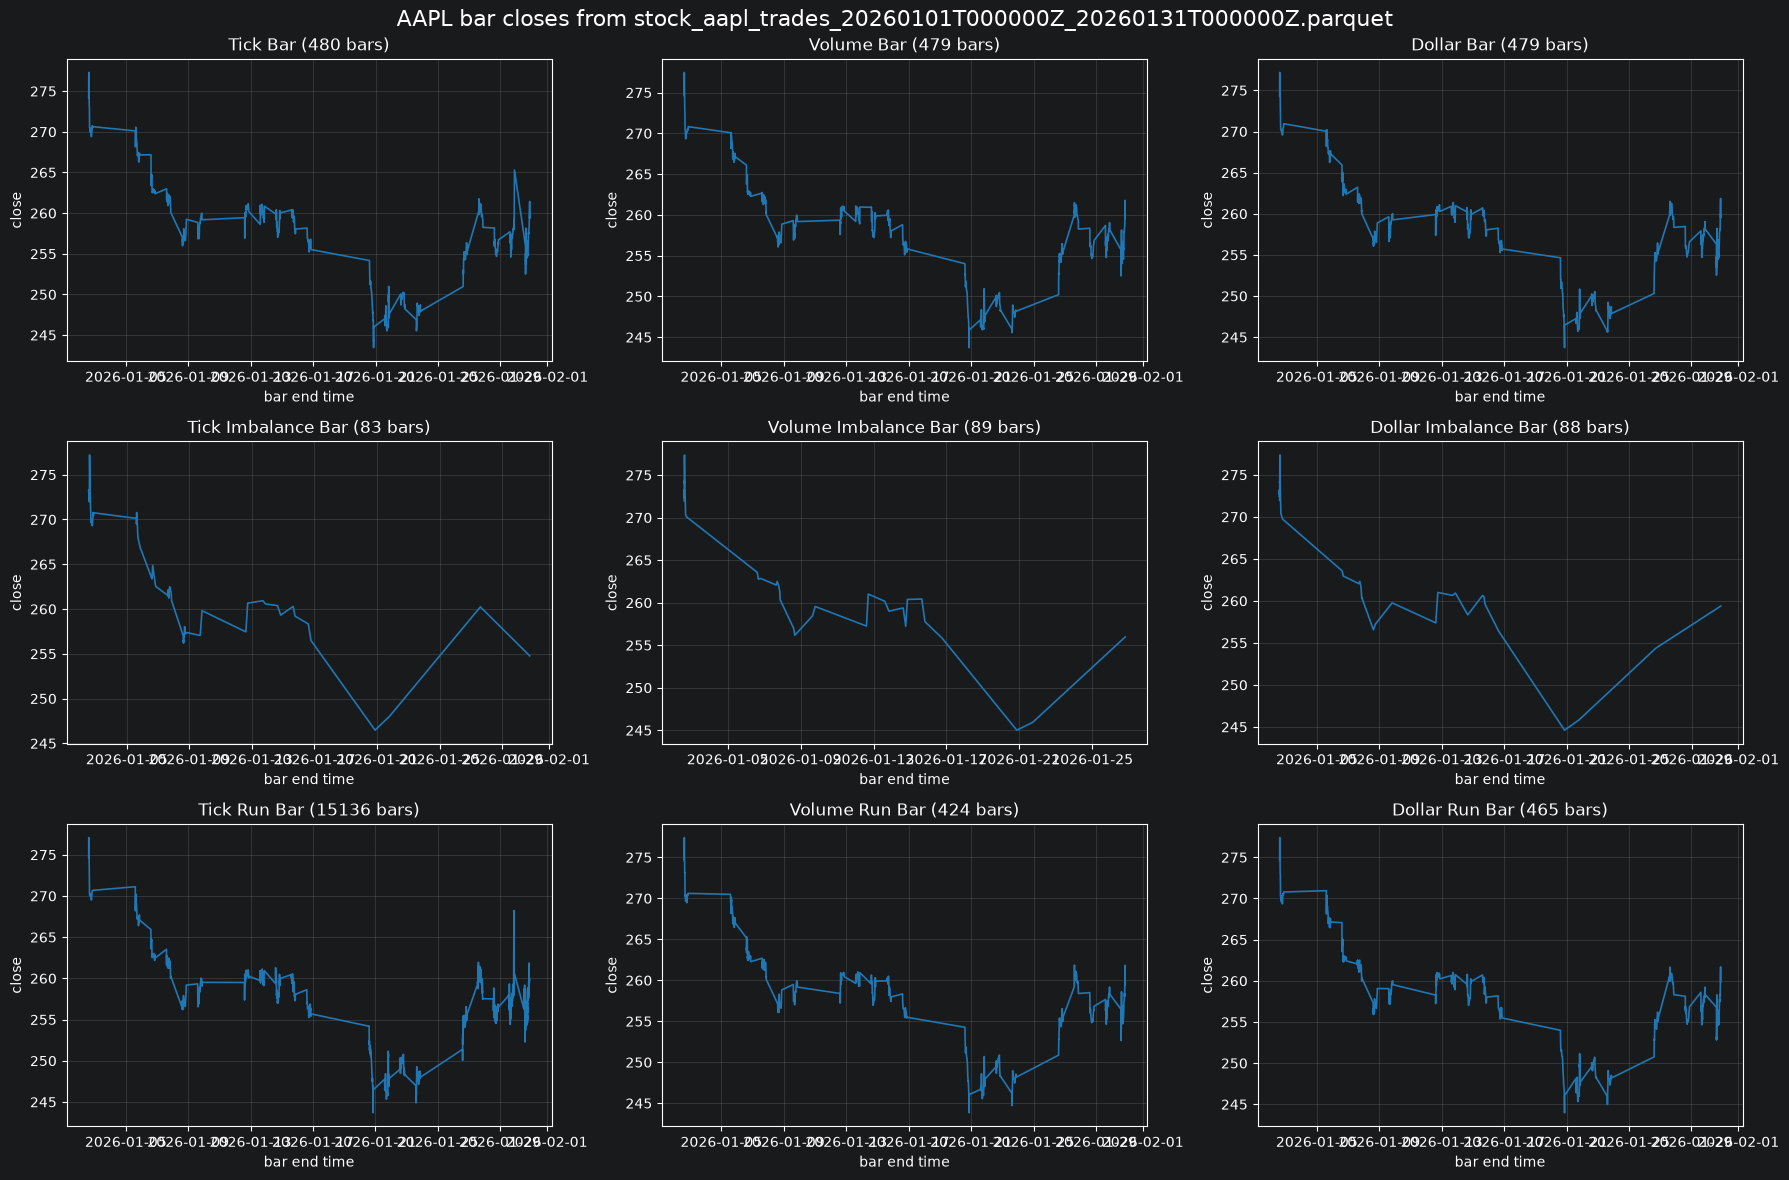

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=False)
axes = axes.ravel()

for ax, (name, result) in zip(axes, bar_results.items()):
    ohlcv = result.ohlcv
    ax.plot(ohlcv.index, ohlcv["close"], color="tab:blue", linewidth=1.2)
    ax.set_title(f"{name} ({len(ohlcv)} bars)")
    ax.set_xlabel("bar end time")
    ax.set_ylabel("close")
    ax.grid(alpha=0.25)

fig.suptitle(f"AAPL bar closes from {alpaca_path.name}", fontsize=16)
fig.tight_layout()

In [6]:
bar_results["Tick Bar"].ohlcv.head()

,start,symbol,open,high,low,close,volume,dollar_value,ticks,buy_volume,sell_volume
end,,,,,,,,,,,
2026-01-02 14:40:11.356469+00:00,2026-01-02 13:27:19.847471+00:00,AAPL,273.230,274.410,271.950,274.190,55156.0,1.507186e+07,846,27985.0,27171.0
2026-01-02 14:49:04.776013+00:00,2026-01-02 14:40:12.410095+00:00,AAPL,274.265,277.360,274.120,277.140,67688.0,1.867253e+07,846,37761.0,29927.0
2026-01-02 15:00:38.050973+00:00,2026-01-02 14:49:04.781591+00:00,AAPL,277.160,277.790,276.640,277.300,61653.0,1.708642e+07,846,30933.0,30720.0
2026-01-02 15:15:56.800419+00:00,2026-01-02 15:00:38.050973+00:00,AAPL,277.300,277.730,275.135,275.245,64786.0,1.792857e+07,846,33959.0,30827.0
2026-01-02 15:32:35.538283+00:00,2026-01-02 15:15:56.813694+00:00,AAPL,275.245,275.465,272.925,273.100,67893.0,1.859374e+07,846,39650.0,28243.0


### Interpretation

The bar summary is already telling you which sampling rules react gently and which ones react aggressively to order flow.
- With the current settings, the standard bars land almost exactly where intended at `480` tick bars, `479` volume bars, and `479` dollar bars, so those three are directly comparable.
- The imbalance bars are much sparser at `83`, `89`, and `88` bars, which means they wait for stronger directional evidence before closing a bar.
- The run bars diverge sharply: `Volume Run Bar` and `Dollar Run Bar` stay in the same broad range as the standard bars (`424` and `465`), while `Tick Run Bar` explodes to `15,136` bars, a sign that its current hyperparameters are far more sensitive on this dataset.


## CUSUM event filter

This section applies `get_cusum_events` to detect timestamps where cumulative signed moves exceed a positive threshold.
- The example uses the dollar-bar close series rather than the raw trade stream.
- That makes the event filter run on a smoother, already-resampled price path.
- The threshold is set to three times the median absolute close-to-close change.
- That choice keeps the example adaptive to the scale of the selected dataset while staying simple to explain.

In [7]:
dollar_close = bar_results["Dollar Bar"].ohlcv["close"]
cusum_threshold = float(dollar_close.diff().abs().median() * 3)
cusum_events = get_cusum_events(dollar_close, threshold=cusum_threshold)

print(f"cusum_threshold: {cusum_threshold:.4f}")
print(f"num_events: {len(cusum_events)}")
cusum_events[:10]

cusum_threshold: 1.2150
num_events: 113


DatetimeIndex(['2026-01-02 14:48:49.651065+00:00',
               '2026-01-02 15:14:20.199050+00:00',
               '2026-01-02 15:30:31.439947+00:00',
               '2026-01-02 16:00:43.210180+00:00',
               '2026-01-02 20:59:21.426171+00:00',
               '2026-01-05 14:38:12.736933+00:00',
               '2026-01-05 14:47:25.900839+00:00',
               '2026-01-05 16:04:56.831469+00:00',
               '2026-01-05 17:24:32.157905+00:00',
               '2026-01-05 19:30:45.766413+00:00'],
              dtype='datetime64[us, UTC]', freq=None)

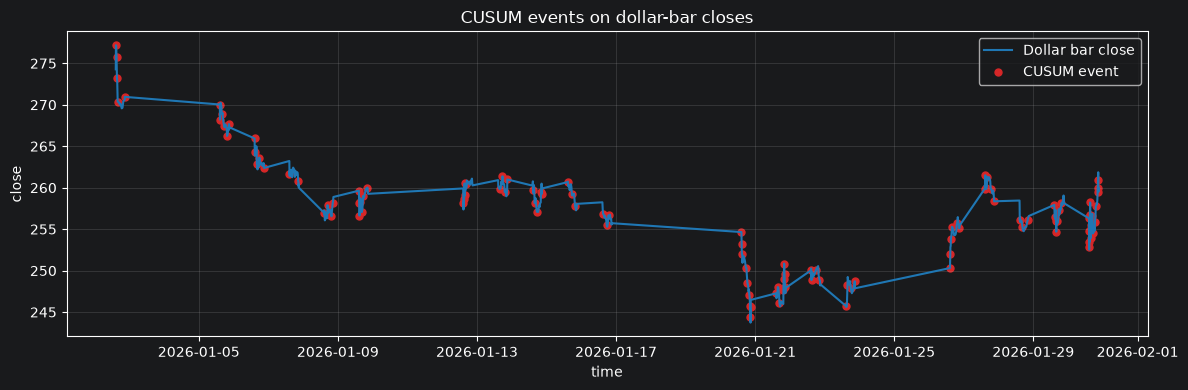

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dollar_close.index, dollar_close, label="Dollar bar close", color="tab:blue")
ax.scatter(cusum_events, dollar_close.loc[cusum_events], color="tab:red", s=25, label="CUSUM event")
ax.set_title("CUSUM events on dollar-bar closes")
ax.set_xlabel("time")
ax.set_ylabel("close")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

### Interpretation

The CUSUM overlay compresses the dollar-bar path into a smaller set of points where price changes were large enough to matter.
- On this run the dollar-bar close series has `479` bars, but the CUSUM filter with threshold about `1.215` keeps only `113` event timestamps, so most quiet bars are deliberately ignored.
- That gap between `479` bars and `113` events is the point of the filter: it shifts the notebook from clock-like sampling toward event-driven sampling.
- If the markers cluster during sharper local moves and thin out during flatter segments of the line plot, the threshold is doing the intended job of suppressing low-information price noise.
